# Toxic Comment Detection Main Training Pipeline
**Model:** SGD Classifier  
**Features:** Word TF-IDF + Char TF-IDF + Engineering Features (Oangsa + Ploy)

## 1. Imports

In [28]:
# !pip install scipy

In [29]:
# !pip install scikit-learn

In [30]:
# !pip install contractions

In [31]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contractions

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)

from optuna.samplers import TPESampler

print('All imports OK')


All imports OK


## 1.5 Constants


In [32]:
DATA_PATH = '../data/train.csv'
LABEL_COLUMNS_TO_DROP = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

SEARCH_RANDOM_STATE = 42
SEARCH_TEST_SIZE = 0.20
SEARCH_CV_SPLITS = 3
OPTUNA_TRIALS_PER_MODEL = 20
SEARCH_CLASS_WEIGHTS = ['balanced', {0:1, 1:3}]

WORD_TFIDF_CONFIG = {
    'ngram_range': (1, 2),
    'max_features': 10000,
    'min_df': 2,
    'max_df': 0.9,
    'sublinear_tf': True,
}
CHAR_TFIDF_CONFIG = {
    'analyzer': 'char_wb',
    'ngram_range': (3, 5),
    'max_features': 10000,
    'min_df': 2,
    'sublinear_tf': True,
}
SCALER_CONFIG = {'with_mean': False}

SGD_OPTUNA_MODEL_BASE_CONFIG = {
    'loss': 'modified_huber',
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}
LR_OPTUNA_MODEL_BASE_CONFIG = {
    'max_iter': 1000,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}
SGD_OPTUNA_ALPHA_RANGE = (1e-5, 1e-3)
SGD_OPTUNA_L1_RATIO_RANGE = (0.05, 0.95)
SGD_OPTUNA_MAX_ITER_RANGE = (750, 1500)
SGD_OPTUNA_TOL_RANGE = (1e-5, 1e-3)
LR_OPTUNA_C_RANGE = (3e-2, 3.0)
LR_OPTUNA_TOL_RANGE = (1e-5, 1e-3)

OPTUNA_WORD_VECTORIZER_PATH = 'optuna_word_vectorizer.pkl'
OPTUNA_CHAR_VECTORIZER_PATH = 'optuna_char_vectorizer.pkl'
OPTUNA_SCALER_PATH = 'optuna_scaler.pkl'
OPTUNA_BEST_MODEL_PATH = 'optuna_best_model.pkl'


## 2. Load & Clean Data

In [33]:
df = pd.read_csv(DATA_PATH)

# keep only toxic label
df = df.drop(columns=LABEL_COLUMNS_TO_DROP)

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['raw_text']   = df['comment_text'].fillna('').astype(str)
df['clean_text'] = df['raw_text'].apply(clean_text)
df = df[df['clean_text'] != ''].copy()
df = df.drop_duplicates(subset=['clean_text'])
df = df.reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(df['toxic'].value_counts())


Dataset shape: (158194, 5)
toxic
0    143038
1     15156
Name: count, dtype: int64


## 3. Feature Engineering

In [34]:
# ── Dictionaries & Patterns ──────────────────────────────────────────────────

PROFANITY_TERMS = [
    'fuck', 'fucking', 'shit', 'bitch', 'bastard', 'asshole', 'idiot', 'moron',
    'dumb', 'stupid', 'suck', 'crap', 'damn', 'jerk', 'loser', 'trash'
]
IDENTITY_TERMS = [
    'black', 'white', 'gay', 'lesbian', 'transgender', 'trans', 'muslim',
    'jewish', 'christian', 'hispanic', 'asian', 'woman', 'women', 'man', 'men'
]
SECOND_PERSON_TERMS = ['you', 'your', 'yours', 'yourself', 'u']
NEGATION_TERMS     = ['not', 'never', 'no', 'none', 'cannot', 'cant', 'do not']
NON_TOXIC_NEGATION_PATTERNS = [
    r'\bnot\s+(?:stupid|dumb|idiot|moron|trash|wrong|bad|terrible|awful|useless)\b',
    r'\bnot\s+(?:an|a)\s+(?:idiot|moron|loser|bastard|fool)\b',
    r'\bdo\s+not\s+(?:like|love|agree|hate|dislike|attack|insult|blame)\b',
    r'\bcannot\s+(?:hate|blame)\b',
    r'\bnot\s+trying\s+to\s+(?:attack|insult|offend)\b',
]
COMMON_SHORT_TOKENS = {
    'i','me','my','you','your','yours','yourself','it','this','that',
    'a','an','the','is','am','are','was','were','be','to','of','and'
}

def make_term_pattern(terms):
    escaped = sorted((re.escape(t) for t in terms), key=len, reverse=True)
    return re.compile(r'\b(?:' + '|'.join(escaped) + r')\b')

PROFANITY_PATTERN          = make_term_pattern(PROFANITY_TERMS)
IDENTITY_PATTERN           = make_term_pattern(IDENTITY_TERMS)
SECOND_PERSON_PATTERN      = make_term_pattern(SECOND_PERSON_TERMS)
NEGATION_PATTERN           = make_term_pattern(NEGATION_TERMS)
NON_TOXIC_NEGATION_PATTERN = re.compile('|'.join(NON_TOXIC_NEGATION_PATTERNS))

def count_pattern(text, pattern):
    return len(pattern.findall(str(text).lower()))

def repeated_characters_score(text):
    return len(re.findall(r'(.)\1{2,}', str(text).lower()))

def repeated_punctuation_count(text):
    return len(re.findall(r'([!?.,])\1+', str(text)))

def uppercase_ratio(text):
    letters = re.findall(r'[A-Za-z]', str(text))
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

def short_unclear_without_toxic_signal(clean_text, profanity_count):
    tokens = str(clean_text).split()
    content_tokens = [t for t in tokens if t not in COMMON_SHORT_TOKENS]
    too_short = len(tokens) < 3 or len(content_tokens) < 1
    return int(too_short and profanity_count == 0)

print('Pattern helpers defined')

Pattern helpers defined


In [35]:
# ── Oangsa features ──────────────────────────────────────────────────────────

df['Character Count']                   = df['raw_text'].apply(len)
df['Word Count']                        = df['clean_text'].apply(lambda x: len(x.split()))
df['Exclamation Count']                 = df['raw_text'].str.count('!')
df['Profanity Count']                   = df['clean_text'].apply(lambda x: count_pattern(x, PROFANITY_PATTERN))
df['Strong Toxic Signal Flag']          = (df['Profanity Count'] > 0).astype(int)
df['Second-person Pronoun Count']       = df['clean_text'].apply(lambda x: count_pattern(x, SECOND_PERSON_PATTERN))
df['Repeated Character Pattern Count'] = df['raw_text'].apply(repeated_characters_score)
df['Average Word Length']               = df['clean_text'].apply(
    lambda x: sum(len(w) for w in x.split()) / len(x.split()) if x.split() else 0
)

# ── Ploy features ─────────────────────────────────────────────────────────────

df['Uppercase Ratio']                         = df['raw_text'].apply(uppercase_ratio)
df['Question Mark Count']                     = df['raw_text'].str.count(r'\?')
df['Repeated Punctuation Count']              = df['raw_text'].apply(repeated_punctuation_count)
df['Identity-group Term Count']               = df['clean_text'].apply(lambda x: count_pattern(x, IDENTITY_PATTERN))
df['URL Count']                               = df['raw_text'].str.count(r'http\S+|www\S+')
df['Negation Count']                          = df['clean_text'].apply(lambda x: count_pattern(x, NEGATION_PATTERN))
df['Non-toxic Negation Pattern Count']        = df['clean_text'].apply(lambda x: count_pattern(x, NON_TOXIC_NEGATION_PATTERN))
df['Short/Unclear Without Toxic Signal Flag'] = df.apply(
    lambda row: short_unclear_without_toxic_signal(row['clean_text'], row['Profanity Count']), axis=1
)

print('Engineering features done')
df.head(3)

Engineering features done


,id,comment_text,toxic,raw_text,clean_text,Character Count,Word Count,Exclamation Count,Profanity Count,Strong Toxic Signal Flag,...,Repeated Character Pattern Count,Average Word Length,Uppercase Ratio,Question Mark Count,Repeated Punctuation Count,Identity-group Term Count,URL Count,Negation Count,Non-toxic Negation Pattern Count,Short/Unclear Without Toxic Signal Flag
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...,264,46,0,0,0,...,0,4.478261,0.083744,1,0,0,0,2,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...,112,16,1,0,0,...,0,4.625000,0.109589,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...,233,44,0,0,0,...,0,4.272727,0.021505,0,0,1,0,1,0,0


## 4. Train / Test Split

In [36]:
ENG_FEATURE_COLS = [
    'Character Count', 'Word Count', 'Exclamation Count',
    'Profanity Count', 'Strong Toxic Signal Flag',
    'Second-person Pronoun Count', 'Repeated Character Pattern Count',
    'Average Word Length',
    'Uppercase Ratio', 'Question Mark Count', 'Repeated Punctuation Count',
    'Identity-group Term Count', 'URL Count', 'Negation Count',
    'Non-toxic Negation Pattern Count', 'Short/Unclear Without Toxic Signal Flag'
]

X_raw   = df['raw_text']
X_clean = df['clean_text']
X_eng   = df[ENG_FEATURE_COLS]
y       = df['toxic']

(
    X_raw_train,   X_raw_test,
    X_clean_train, X_clean_test,
    X_eng_train,   X_eng_test,
    y_train,       y_test
) = train_test_split(
    X_raw, X_clean, X_eng, y,
    test_size=SEARCH_TEST_SIZE,
    random_state=SEARCH_RANDOM_STATE,
    stratify=y,
)

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Toxic ratio (train): {y_train.mean():.3f}')


Train: 126,555  |  Test: 31,639
Toxic ratio (train): 0.096


## 5. Vectorize Text

In [37]:
word_vec = TfidfVectorizer(**WORD_TFIDF_CONFIG)
X_word_train = word_vec.fit_transform(X_clean_train)
X_word_test  = word_vec.transform(X_clean_test)

char_vec = TfidfVectorizer(**CHAR_TFIDF_CONFIG)
X_char_train = char_vec.fit_transform(X_raw_train)
X_char_test  = char_vec.transform(X_raw_test)

print(f'Word TF-IDF : {X_word_train.shape}')
print(f'Char TF-IDF : {X_char_train.shape}')


Word TF-IDF : (126555, 10000)
Char TF-IDF : (126555, 10000)


In [38]:
scaler = StandardScaler(**SCALER_CONFIG)
X_eng_train_scaled = scaler.fit_transform(X_eng_train.values)
X_eng_test_scaled  = scaler.transform(X_eng_test.values)

X_train = hstack([X_word_train, X_char_train, csr_matrix(X_eng_train_scaled)], format='csr')
X_test  = hstack([X_word_test,  X_char_test,  csr_matrix(X_eng_test_scaled)], format='csr')

print(f'Final feature matrix (train): {X_train.shape}')
print(f'Final feature matrix (test) : {X_test.shape}')


Final feature matrix (train): (126555, 20016)
Final feature matrix (test) : (31639, 20016)


5.5 Automated parameter tuning with Optuna

In [39]:
import optuna
print(f'optuna version: {optuna.__version__}')


optuna version: 4.8.0


In [40]:

search_cv = StratifiedKFold(
    n_splits=SEARCH_CV_SPLITS,
    shuffle=True,
    random_state=SEARCH_RANDOM_STATE,
)

def suggest_class_weight(trial, prefix):
    idx = trial.suggest_int(f'{prefix}_class_weight_idx', 0, len(SEARCH_CLASS_WEIGHTS) - 1)
    return SEARCH_CLASS_WEIGHTS[idx]


def objective_sgd(trial):
    model = SGDClassifier(
        loss='modified_huber',
        alpha=trial.suggest_float('alpha', SGD_OPTUNA_ALPHA_RANGE[0], SGD_OPTUNA_ALPHA_RANGE[1], log=True),
        penalty=trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        l1_ratio=trial.suggest_float('l1_ratio', SGD_OPTUNA_L1_RATIO_RANGE[0], SGD_OPTUNA_L1_RATIO_RANGE[1]),
        class_weight=suggest_class_weight(trial, 'sgd'),
        max_iter=trial.suggest_int('max_iter', SGD_OPTUNA_MAX_ITER_RANGE[0], SGD_OPTUNA_MAX_ITER_RANGE[1]),
        tol=trial.suggest_float('tol', SGD_OPTUNA_TOL_RANGE[0], SGD_OPTUNA_TOL_RANGE[1], log=True),
        random_state=SEARCH_RANDOM_STATE,
        n_jobs=None,
    )
    return cross_val_score(model, X_train, y_train, cv=search_cv, scoring='f1', n_jobs=-1).mean()


def objective_lr(trial):
    model = LogisticRegression(
        solver='liblinear',
        penalty=trial.suggest_categorical('penalty', ['l1', 'l2']),
        C=trial.suggest_float('C', LR_OPTUNA_C_RANGE[0], LR_OPTUNA_C_RANGE[1], log=True),
        class_weight=suggest_class_weight(trial, 'lr'),
        tol=trial.suggest_float('tol', LR_OPTUNA_TOL_RANGE[0], LR_OPTUNA_TOL_RANGE[1], log=True),
        max_iter=1000,
        random_state=SEARCH_RANDOM_STATE,
        n_jobs=None,
    )

    return cross_val_score(model, X_train, y_train, cv=search_cv, scoring='f1', n_jobs=-1).mean()

print(f'Running Optuna SGD study ({OPTUNA_TRIALS_PER_MODEL} trials x {SEARCH_CV_SPLITS}-fold)...')
sgd_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEARCH_RANDOM_STATE))
sgd_study.optimize(objective_sgd, n_trials=OPTUNA_TRIALS_PER_MODEL)

print(f'Running Optuna LR study ({OPTUNA_TRIALS_PER_MODEL} trials x {SEARCH_CV_SPLITS}-fold)...')
lr_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEARCH_RANDOM_STATE))
lr_study.optimize(objective_lr, n_trials=OPTUNA_TRIALS_PER_MODEL)

def materialize_best_params(best_params, prefix):
    params = dict(best_params)
    idx_key = f'{prefix}_class_weight_idx'
    if idx_key in params:
        params['class_weight'] = SEARCH_CLASS_WEIGHTS[params.pop(idx_key)]
    return params

best_sgd_params = materialize_best_params(sgd_study.best_params, 'sgd')
best_lr_params = materialize_best_params(lr_study.best_params, 'lr')

best_sgd = SGDClassifier(
    **SGD_OPTUNA_MODEL_BASE_CONFIG,
    **best_sgd_params,
)
best_sgd.fit(X_train, y_train)

best_lr = LogisticRegression(
    **LR_OPTUNA_MODEL_BASE_CONFIG,
    **best_lr_params,
)
best_lr.fit(X_train, y_train)

print('\nOptuna search complete')
print(f'SGD best CV F1 : {sgd_study.best_value:.4f}')
print(f'SGD best params: {best_sgd_params}')
print(f'LR best CV F1  : {lr_study.best_value:.4f}')
print(f'LR best params : {best_lr_params}')


[I 2026-05-14 05:25:32,225] A new study created in memory with name: no-name-2842d3e4-98c7-4773-8ba5-58248ab34038


Running Optuna SGD study (20 trials x 3-fold)...


[I 2026-05-14 05:25:46,159] Trial 0 finished with value: 0.6678430194862175 and parameters: {'alpha': 5.6115164153345e-05, 'penalty': 'l2', 'l1_ratio': 0.19041677639819288, 'sgd_class_weight_idx': 0, 'max_iter': 793, 'tol': 0.0005399484409787432}. Best is trial 0 with value: 0.6678430194862175.
[I 2026-05-14 05:26:35,159] Trial 1 finished with value: 0.6845716367742755 and parameters: {'alpha': 0.00015930522616241006, 'penalty': 'elasticnet', 'l1_ratio': 0.7991983767203795, 'sgd_class_weight_idx': 0, 'max_iter': 886, 'tol': 2.3270677083837777e-05}. Best is trial 1 with value: 0.6845716367742755.
[I 2026-05-14 05:26:40,705] Trial 2 finished with value: 0.670048848904317 and parameters: {'alpha': 4.059611610484306e-05, 'penalty': 'l2', 'l1_ratio': 0.6006676052501415, 'sgd_class_weight_idx': 0, 'max_iter': 969, 'tol': 5.4041038546473305e-05}. Best is trial 1 with value: 0.6845716367742755.
[I 2026-05-14 05:26:46,261] Trial 3 finished with value: 0.6991627792716487 and parameters: {'alpha'

Running Optuna LR study (20 trials x 3-fold)...


[I 2026-05-14 05:50:10,120] Trial 0 finished with value: 0.7879219252496821 and parameters: {'penalty': 'l2', 'C': 0.8731907739399206, 'lr_class_weight_idx': 1, 'tol': 2.0513382630874486e-05}. Best is trial 0 with value: 0.7879219252496821.
[I 2026-05-14 05:50:31,620] Trial 1 finished with value: 0.784239700940244 and parameters: {'penalty': 'l1', 'C': 1.6198453229362295, 'lr_class_weight_idx': 1, 'tol': 0.0002607024758370766}. Best is trial 0 with value: 0.7879219252496821.
[I 2026-05-14 05:59:14,969] Trial 2 finished with value: 0.7506540850291855 and parameters: {'penalty': 'l2', 'C': 1.386776700306249, 'lr_class_weight_idx': 0, 'tol': 2.3102018878452926e-05}. Best is trial 0 with value: 0.7879219252496821.
[I 2026-05-14 06:04:19,224] Trial 3 finished with value: 0.7310239542337836 and parameters: {'penalty': 'l2', 'C': 0.33622818635581697, 'lr_class_weight_idx': 0, 'tol': 3.8234752246751835e-05}. Best is trial 0 with value: 0.7879219252496821.
[I 2026-05-14 06:04:28,822] Trial 4 fi


Optuna search complete
SGD best CV F1 : 0.7751
SGD best params: {'alpha': 0.0003498227300675482, 'penalty': 'elasticnet', 'l1_ratio': 0.05525020077909619, 'max_iter': 1386, 'tol': 0.00021601863672613563, 'class_weight': {0: 1, 1: 3}}
LR best CV F1  : 0.7883
LR best params : {'penalty': 'l2', 'C': 2.873703917194986, 'tol': 0.0002479201332659857, 'class_weight': {0: 1, 1: 3}}


## 6. Evaluate Tuned Models


In [41]:
models = {
    'Tuned SGD': best_sgd,
    'Tuned LR': best_lr,
}

scores = {}
for name, estimator in models.items():
    y_pred = estimator.predict(X_test)
    y_prob = estimator.predict_proba(X_test)[:, 1]
    scores[name] = {
        'pred': y_pred,
        'prob': y_prob,
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }

print(f"{'Model':<12} {'F1':>8} {'ROC-AUC':>10}")
print('-' * 32)
for name, metrics in scores.items():
    print(f"{name:<12} {metrics['f1']:>8.4f} {metrics['roc_auc']:>10.4f}")


Model              F1    ROC-AUC
--------------------------------
Tuned SGD      0.7715     0.9722
Tuned LR       0.7853     0.9731


## 7. Evaluate

In [42]:
for name in ['Tuned SGD', 'Tuned LR']:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, scores[name]['pred'], target_names=['Not Toxic', 'Toxic']))
    print(f"ROC-AUC : {scores[name]['roc_auc']:.4f}")
    print(f"F1      : {scores[name]['f1']:.4f}")



=== Tuned SGD ===
              precision    recall  f1-score   support

   Not Toxic       0.98      0.97      0.97     28608
       Toxic       0.75      0.79      0.77      3031

    accuracy                           0.95     31639
   macro avg       0.86      0.88      0.87     31639
weighted avg       0.96      0.95      0.96     31639

ROC-AUC : 0.9722
F1      : 0.7715

=== Tuned LR ===
              precision    recall  f1-score   support

   Not Toxic       0.98      0.98      0.98     28608
       Toxic       0.78      0.79      0.79      3031

    accuracy                           0.96     31639
   macro avg       0.88      0.89      0.88     31639
weighted avg       0.96      0.96      0.96     31639

ROC-AUC : 0.9731
F1      : 0.7853


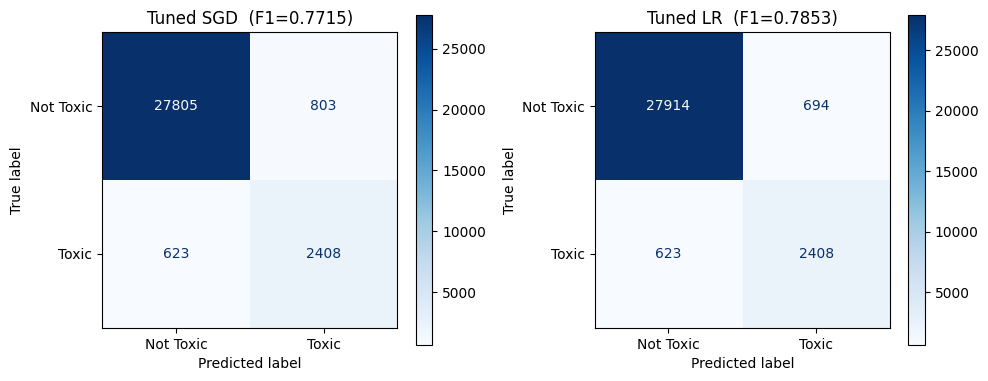

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['Tuned SGD', 'Tuned LR']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, scores[name]['pred'],
        display_labels=['Not Toxic', 'Toxic'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f"{name}  (F1={scores[name]['f1']:.4f})")
plt.tight_layout()
plt.show()


In [44]:
result_df = pd.DataFrame({
    name: {
        'F1': metrics['f1'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'ROC-AUC': metrics['roc_auc'],
        'Best CV F1': sgd_study.best_value if name == 'Tuned SGD' else lr_study.best_value,
    }
    for name, metrics in scores.items()
}).T.round(4)

print('=== Optuna Model Comparison ===')
print(result_df.to_string())


=== Optuna Model Comparison ===
               F1  Precision  Recall  ROC-AUC  Best CV F1
Tuned SGD  0.7715     0.7499  0.7945   0.9722      0.7751
Tuned LR   0.7853     0.7763  0.7945   0.9731      0.7883


In [45]:
print('Threshold sweep removed so the Optuna notebook stays model-only and directly comparable to the other tuning notebooks.')


Threshold sweep removed so the Optuna notebook stays model-only and directly comparable to the other tuning notebooks.


In [46]:
best_name = max(scores, key=lambda name: scores[name]['f1'])
best_model = models[best_name]

print(f'Best overall model : {best_name}')
print(f'Test F1            : {scores[best_name]["f1"]:.4f}')


Best overall model : Tuned LR
Test F1            : 0.7853


In [47]:
with open(OPTUNA_WORD_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(word_vec, f)

with open(OPTUNA_CHAR_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(char_vec, f)

with open(OPTUNA_SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

with open(OPTUNA_BEST_MODEL_PATH, 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved: {OPTUNA_BEST_MODEL_PATH}')
print(f'Saved: {OPTUNA_WORD_VECTORIZER_PATH} / {OPTUNA_CHAR_VECTORIZER_PATH} / {OPTUNA_SCALER_PATH}')


Saved: optuna_best_model.pkl
Saved: optuna_word_vectorizer.pkl / optuna_char_vectorizer.pkl / optuna_scaler.pkl


## 8. Save Model & Artifacts

In [48]:
print('Artifacts were already saved with method-specific names in the previous cell.')


Artifacts were already saved with method-specific names in the previous cell.


## 8. Inference Helper


In [49]:
def predict_toxicity(comment: str) -> dict:
    """Predict whether a comment is toxic using the best Optuna-tuned model."""
    raw   = comment
    clean = clean_text(comment)

    profanity = count_pattern(clean, PROFANITY_PATTERN)
    eng = pd.DataFrame([{
        'Character Count':                    len(raw),
        'Word Count':                         len(clean.split()),
        'Exclamation Count':                  raw.count('!'),
        'Profanity Count':                    profanity,
        'Strong Toxic Signal Flag':           int(profanity > 0),
        'Second-person Pronoun Count':        count_pattern(clean, SECOND_PERSON_PATTERN),
        'Repeated Character Pattern Count':   repeated_characters_score(raw),
        'Average Word Length':                sum(len(w) for w in clean.split()) / max(len(clean.split()), 1),
        'Uppercase Ratio':                    uppercase_ratio(raw),
        'Question Mark Count':                raw.count('?'),
        'Repeated Punctuation Count':         repeated_punctuation_count(raw),
        'Identity-group Term Count':          count_pattern(clean, IDENTITY_PATTERN),
        'URL Count':                          len(re.findall(r'http\S+|www\S+', raw)),
        'Negation Count':                     count_pattern(clean, NEGATION_PATTERN),
        'Non-toxic Negation Pattern Count':   count_pattern(clean, NON_TOXIC_NEGATION_PATTERN),
        'Short/Unclear Without Toxic Signal Flag': short_unclear_without_toxic_signal(clean, profanity),
    }])

    X_w  = word_vec.transform([clean])
    X_c  = char_vec.transform([raw])
    X_e  = csr_matrix(scaler.transform(eng.values))
    X    = hstack([X_w, X_c, X_e], format='csr')

    label = best_model.predict(X)[0]
    prob  = best_model.predict_proba(X)[0][1]

    return {'label': 'Toxic' if label == 1 else 'Not Toxic', 'probability': round(prob, 4)}


samples = [
    'You are such an idiot, go fuck yourself!',
    'Thanks for explaining the issue, that really helped!',
    'I do not think this policy is fair to everyone.',
]

for s in samples:
    result = predict_toxicity(s)
    print(f"{result['label']:10s} ({result['probability']:.2%})  ->  {s[:60]}")


Toxic      (100.00%)  ->  You are such an idiot, go fuck yourself!
Not Toxic  (0.37%)  ->  Thanks for explaining the issue, that really helped!
Not Toxic  (0.38%)  ->  I do not think this policy is fair to everyone.
